# Time Series Graphics

## Parsing dates

In [1]:
!head data/olympic_running.csv

Year,Length,Sex,Time
1896,100,men,12
1900,100,men,11
1904,100,men,11
1908,100,men,10.8
1912,100,men,10.8
1916,100,men,NA
1920,100,men,10.8
1924,100,men,10.6
1928,100,men,10.8


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf


In [3]:
olympic_running = pd.read_csv('data/olympic_running.csv', parse_dates=["Year"])
olympic_running

,Year,Length,Sex,Time
0,1896-01-01,100,men,12.00
1,1900-01-01,100,men,11.00
2,1904-01-01,100,men,11.00
3,1908-01-01,100,men,10.80
4,1912-01-01,100,men,10.80
...,...,...,...,...
307,2000-01-01,10000,women,1817.49
308,2004-01-01,10000,women,1824.36
309,2008-01-01,10000,women,1794.66
310,2012-01-01,10000,women,1820.75


In [4]:
olympic_running.dtypes

Year      datetime64[ns]
Length             int64
Sex               object
Time             float64
dtype: object

In [5]:
pbs = pd.read_csv("data/PBS.csv", parse_dates = ['Month'])
pbs

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_16991/4106293591.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pbs = pd.read_csv("data/PBS.csv", parse_dates = ['Month'])


,Month,Concession,Type,ATC1,ATC1_desc,ATC2,ATC2_desc,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,14371,52120.0
...,...,...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,NaN,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,NaN,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,NaN,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,NaN,Z,Z,21,278.0


In [6]:
pbs.dtypes

Month         datetime64[ns]
Concession            object
Type                  object
ATC1                  object
ATC1_desc             object
ATC2                  object
ATC2_desc             object
Scripts                int64
Cost                 float64
dtype: object

In [7]:
pbs['ATC2_desc'].value_counts()

ATC2_desc
STOMATOLOGICAL PREPARATIONS                    816
ANTIMYCOBACTERIALS                             816
ANTIINFLAMMATORY AND ANTIRHEUMATIC PRODUCTS    816
IMMUNOSUPPRESSIVE AGENTS                       816
ENDOCRINE THERAPY                              816
                                              ... 
D                                              536
IMMUNE SERA AND IMMUNOGLOBULINS                528
VASOPROTECTIVES                                500
BILE AND LIVER THERAPY                         384
R                                              296
Name: count, Length: 84, dtype: int64

In [8]:
def summarize(gb, f):
    return gb.apply(lambda x: pd.Series(f(x)))

In [9]:
a10 = pbs.loc[pbs['ATC2']=='A10']
a10 = a10.groupby('Month')['Cost'].sum()
a10 = a10/1e6
a10 = a10.reset_index()
a10.set_index("Month", inplace=True, drop=False)
a10

,Month,Cost
Month,,
1991-07-01,1991-07-01,3.526591
1991-08-01,1991-08-01,3.180891
1991-09-01,1991-09-01,3.252221
1991-10-01,1991-10-01,3.611003
1991-11-01,1991-11-01,3.565869
...,...,...
2008-02-01,2008-02-01,21.654285
2008-03-01,2008-03-01,18.264945
2008-04-01,2008-04-01,23.107677


In [10]:
a10 = (
    pbs
    .query('ATC2 == "A10"')
    .groupby('Month', sort=False)[["Cost"]]
    .apply(lambda x: pd.Series({"Cost": x["Cost"].sum() / 1e6}))
    .reset_index()
    .set_index('Month', drop=False)
)


In [11]:
!head data/ansett.csv

Week,Airports,Class,Passengers
1989 W28,ADL-PER,Business,193
1989 W29,ADL-PER,Business,254
1989 W30,ADL-PER,Business,185
1989 W31,ADL-PER,Business,254
1989 W32,ADL-PER,Business,191
1989 W33,ADL-PER,Business,136
1989 W34,ADL-PER,Business,0
1989 W35,ADL-PER,Business,0
1989 W36,ADL-PER,Business,0


In [12]:
ansett = pd.read_csv("data/ansett.csv", parse_dates=['Week'])

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_16991/3172126305.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ansett = pd.read_csv("data/ansett.csv", parse_dates=['Week'])


In [13]:
ansett.dtypes

Week          object
Airports      object
Class         object
Passengers     int64
dtype: object

In [14]:
def ansett_parse_week(week):
    y = int(week[:4])
    w = int(week[-2:])
    return pd.to_datetime(y, format='%Y') + pd.to_timedelta(w, 'w')

In [15]:
ansett = pd.read_csv('data/ansett.csv')  # Sem parse_dates

# Converter a coluna 'Week' usando a mesma lógica da função original
ansett['Week'] = (
    ansett['Week']
    .astype(str)  # Garante que os valores são strings
    .apply(lambda week: pd.to_datetime(int(week[:4]), format='%Y') + pd.to_timedelta(int(week[-2:]), 'w'))
)
ansett

,Week,Airports,Class,Passengers
0,1989-07-16,ADL-PER,Business,193
1,1989-07-23,ADL-PER,Business,254
2,1989-07-30,ADL-PER,Business,185
3,1989-08-06,ADL-PER,Business,254
4,1989-08-13,ADL-PER,Business,191
...,...,...,...,...
7402,1992-10-28,SYD-PER,First,203
7403,1992-11-04,SYD-PER,First,137
7404,1992-11-11,SYD-PER,First,161
7405,1992-11-18,SYD-PER,First,155


In [16]:
ansett.dtypes

Week          datetime64[ns]
Airports              object
Class                 object
Passengers             int64
dtype: object

## Time Series Graphics

In [17]:
melsyd_economy = ansett.loc[(ansett['Airports']=='MEL-SYD')&(ansett['Class']=='Economy')]

In [18]:
melsyd_economy

,Week,Airports,Class,Passengers
3881,1987-07-02,MEL-SYD,Economy,20167
3882,1987-07-09,MEL-SYD,Economy,20161
3883,1987-07-16,MEL-SYD,Economy,19993
3884,1987-07-23,MEL-SYD,Economy,20986
3885,1987-07-30,MEL-SYD,Economy,20497
...,...,...,...,...
4158,1992-10-28,MEL-SYD,Economy,28837
4159,1992-11-04,MEL-SYD,Economy,26548
4160,1992-11-11,MEL-SYD,Economy,27279
4161,1992-11-18,MEL-SYD,Economy,27306


In [19]:
melsyd_economy.set_index('Week', inplace=True)

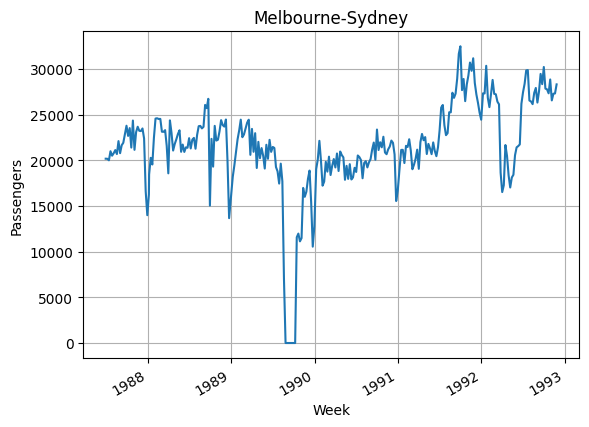

In [20]:
ax = melsyd_economy['Passengers'].plot()
ax.set(ylabel='Passengers', title='Melbourne-Sydney')
ax.grid()

* There was a period in 1989 when no passengers were carried - this was due to an industrial dispute

## Time series patterns

* Trend: pattern exists when there is a long-term increase or decrease in the data.
* Seasonal: pattern exists when a series is influenced by seasonal factors (e.g., the quarter of the year, the month, or day of the week)
* Cyclic: pattern exists when data exhibit rises and falls that are not of fixed period (duration usually of at least 2 years)

In [21]:
a10

,Month,Cost
Month,,
1991-07-01,1991-07-01,3.526591
1991-08-01,1991-08-01,3.180891
1991-09-01,1991-09-01,3.252221
1991-10-01,1991-10-01,3.611003
1991-11-01,1991-11-01,3.565869
...,...,...
2008-02-01,2008-02-01,21.654285
2008-03-01,2008-03-01,18.264945
2008-04-01,2008-04-01,23.107677


Text(0, 0.5, '$(millions)')

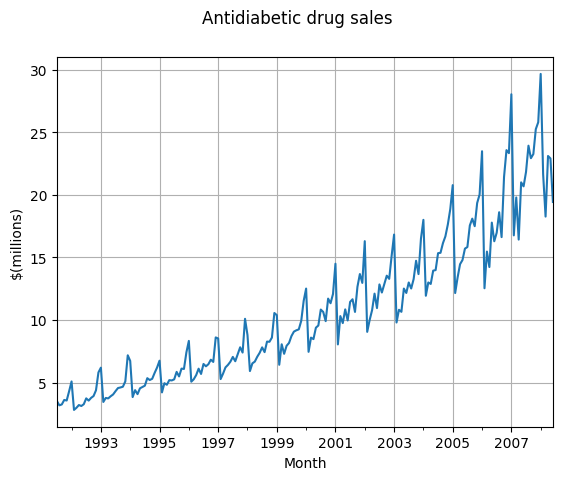

In [22]:
a10['Cost'].plot(grid=True)
plt.suptitle("Antidiabetic drug sales")
plt.ylabel("$(millions)")

![nasdaq](img/tspatters.png)

## Time series patterns

* Trend: a long-term increase or decrease in the data. It does not have to be linear.
* Seasonal: seasonal factors such as the time of the year or the day of the week. Fixed and known period.
* Cyclic: data exhibit rises and fails that are not of a fixed frequency.

## Time series components
* seasonal pattern constant length; cyclic pattern variable length
* average length of cycle longer than length of seasonal pattern
* magnitude of cycle more variable than magnitude of seasonal pattern

In [24]:
def compute(df, f):
    """Compute new (or replacement) columns."""
    new_cols = f(df)
    return df.assign(**new_cols)

In [25]:
aus_production = pd.read_csv('data/aus_production.csv')
aus_production = (
    aus_production
    .assign(Date=pd.to_datetime(aus_production.Quarter.str.replace(' ', '')))
    .pipe(compute, lambda x: dict(Year=x.Date.dt.year))
    .set_index('Date', drop=False)
)


/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_16991/238764111.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(Date=pd.to_datetime(aus_production.Quarter.str.replace(' ', '')))


In [26]:
aus_production

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1956-01-01,1956 Q1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1956-04-01,1956 Q2,213,5178.0,204.0,532,4436,6,1956-04-01,1956
1956-07-01,1956 Q3,227,5297.0,208.0,561,4806,7,1956-07-01,1956
1956-10-01,1956 Q4,308,5681.0,197.0,570,4418,6,1956-10-01,1956
1957-01-01,1957 Q1,262,5577.0,187.0,529,4339,5,1957-01-01,1957
...,...,...,...,...,...,...,...,...,...
2009-04-01,2009 Q2,398,NaN,NaN,2160,57471,238,2009-04-01,2009
2009-07-01,2009 Q3,419,NaN,NaN,2325,58394,252,2009-07-01,2009
2009-10-01,2009 Q4,488,NaN,NaN,2273,57336,210,2009-10-01,2009


In [26]:
aus_production.columns

Index(['Quarter', 'Beer', 'Tobacco', 'Bricks', 'Cement', 'Electricity', 'Gas',
       'Date', 'Year'],
      dtype='object')

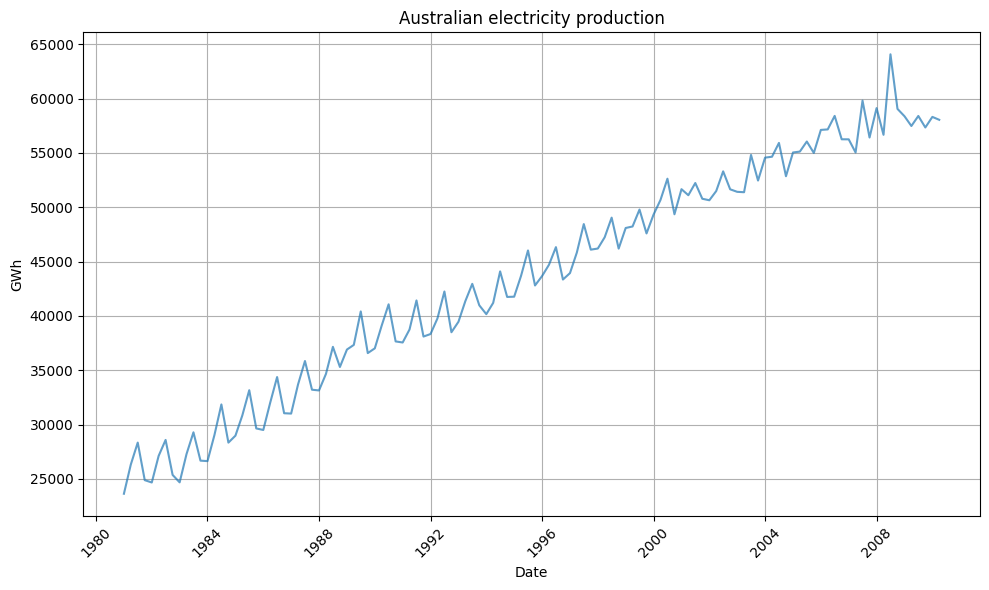

In [27]:
plt.figure(figsize=(10, 6))
df = aus_production.query("Year > 1980")
plt.plot(df.index, df['Electricity'], marker='', linestyle='-', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('GWh')
plt.title('Australian electricity production')

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

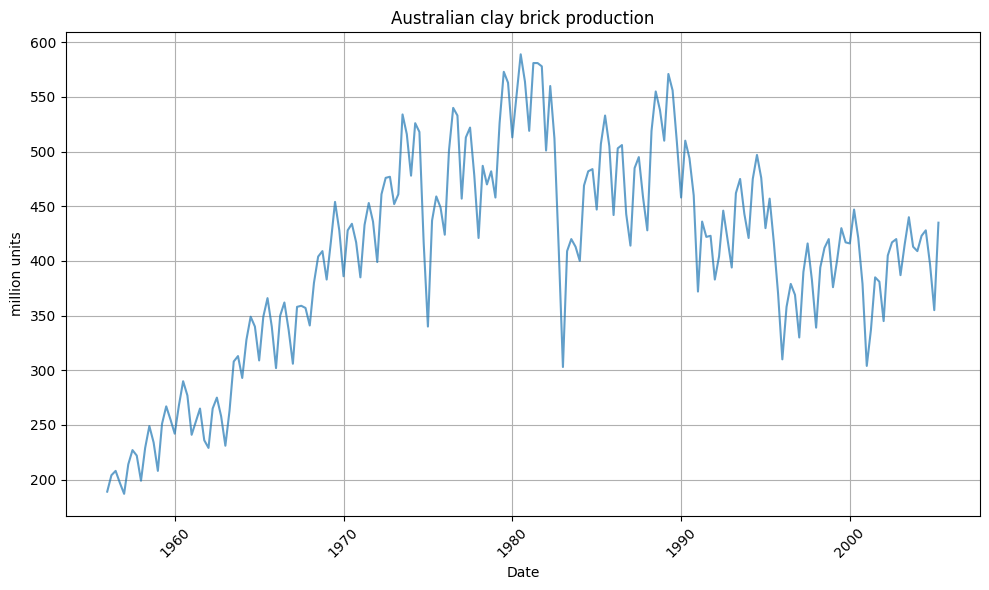

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(aus_production.index, aus_production['Bricks'], marker='', linestyle='-', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('million units')
plt.title('Australian clay brick production')

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
!head data/aus_production.csv

Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
1956 Q1,284,5225,189,465,3923,5
1956 Q2,213,5178,204,532,4436,6
1956 Q3,227,5297,208,561,4806,7
1956 Q4,308,5681,197,570,4418,6
1957 Q1,262,5577,187,529,4339,5
1957 Q2,228,5651,214,604,4811,7
1957 Q3,236,5317,227,603,5259,7
1957 Q4,320,6152,222,582,4735,6
1958 Q1,272,5758,199,554,4608,5


In [29]:
!head data/gafa_stock.csv

Symbol,Date,Open,High,Low,Close,Adj_Close,Volume
AAPL,2014-01-02,79.382858,79.575714,78.860001,79.01857,66.964325,58671200
AAPL,2014-01-03,78.980003,79.099998,77.204285,77.28286,65.493416,98116900
AAPL,2014-01-06,76.778572,78.114288,76.228569,77.704285,65.850533,103152700
AAPL,2014-01-07,77.760002,77.994286,76.845711,77.148575,65.379593,79302300
AAPL,2014-01-08,76.972855,77.937141,76.955711,77.637146,65.793633,64632400
AAPL,2014-01-09,78.114288,78.122856,76.478569,76.645714,64.953445,69787200
AAPL,2014-01-10,77.118568,77.257141,75.872856,76.134285,64.520035,76244000
AAPL,2014-01-13,75.701431,77.5,75.697144,76.53286,64.857819,94623200
AAPL,2014-01-14,76.888573,78.104286,76.808571,78.055717,66.148376,83140400


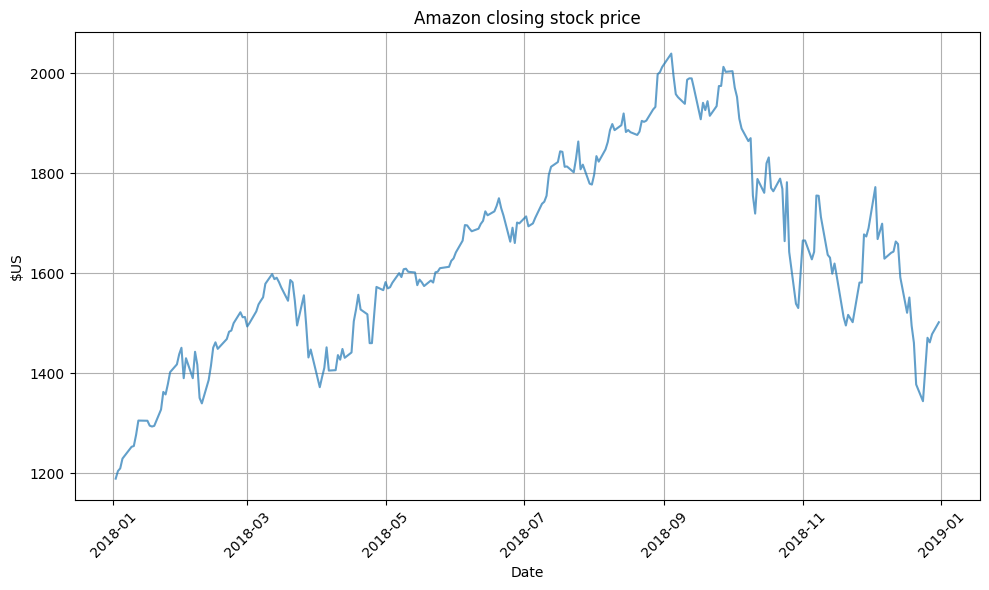

In [30]:
gafa_stock = pd.read_csv('data/gafa_stock.csv', parse_dates=['Date'])
amzn = gafa_stock.loc[(gafa_stock['Symbol']=='AMZN')&(gafa_stock['Date']>="2018-01-01")]

plt.figure(figsize=(10, 6))
plt.plot(amzn['Date'], amzn['Close'], marker='', linestyle='-', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('$US')
plt.title('Amazon closing stock price')

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
!head data/lynx.csv

rownames,time,value
1,1821,269
2,1822,321
3,1823,585
4,1824,871
5,1825,1475
6,1826,2821
7,1827,3928
8,1828,5943
9,1829,4950


In [32]:
lynx = pd.read_csv('data/lynx.csv', parse_dates=['time'])

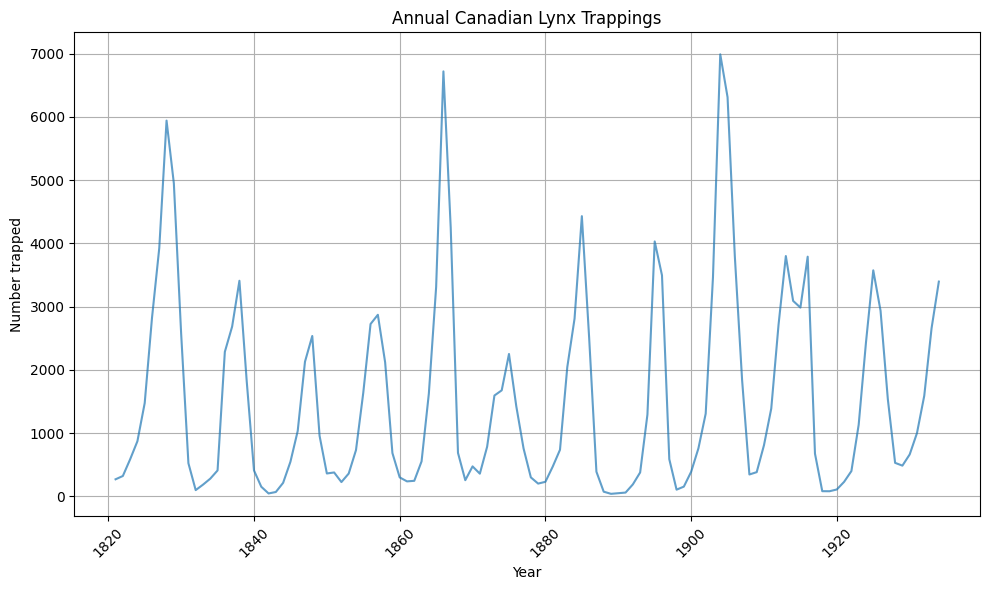

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(lynx.time, lynx.value, marker='', linestyle='-', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Number trapped')
plt.title('Annual Canadian Lynx Trappings')

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Seasonal or cyclic?

* seasonal pattern constant length; cyclic pattern variable length
* average length of cycle longer than length of sesonal pattern
* magnitude of cycle more variable than magnitude of seasonal pattern

>The timing of peaks and throughs is predictable with seasonal data, but unpredictable in the long term with cyclic data

## Seasonal plots



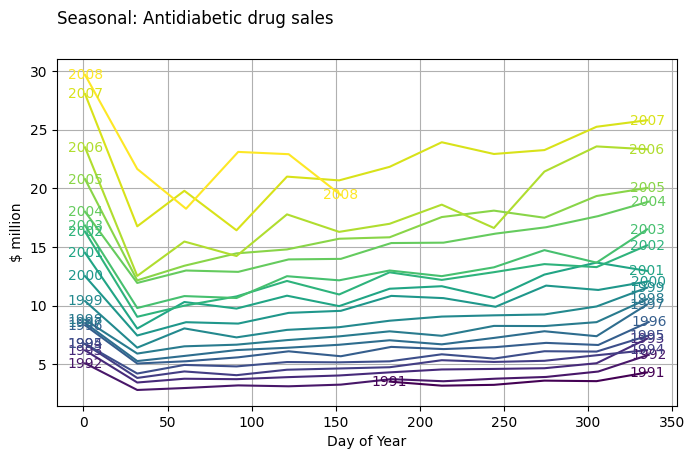

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

def seasonalize(data, column, period='year'):
    data = data.copy()

    if period.lower() in ('year', 'y'):
        data["__period"] = data.index.year
        data["__x"] = data.index.dayofyear
    elif period.lower() in ('week', 'w'):
        data["__period"] = 100 * data.index.year + data.index.isocalendar().week
        data["__x"] = data.index.dayofweek + data.index.hour / 24 + data.index.minute / 1440 + data.index.second / 86400
    elif period.lower() in ('day', 'd'):
        data["__period"] = data.index.date
        data["__x"] = data.index.hour + data.index.minute / 60 + data.index.second / 3600
    else:
        raise ValueError("Invalid period. Choose from 'year', 'week', or 'day'.")

    return (
        data.sort_values("__x")
        .groupby("__period")[[column, "__x"]]  # <-- Mantemos apenas colunas necessárias
        .apply(lambda x: pd.DataFrame({'time': x["__x"].values, column: x[column].values}))
        .reset_index(level=0)
    )



def plot_seasonal(data, column, period='year', cmap='viridis', labels='', figsize=None, ax=None, **kw):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig, ax = ax.figure, ax

    d = seasonalize(data, column, period)
    cm = plt.get_cmap(cmap)
    periods = d["__period"].unique()
    colors = cm(np.linspace(0, 1, len(periods)))

    for color, (period, group) in zip(colors, d.groupby("__period")):
        ax.plot(group["time"], group[column], color=color, label=str(period), **kw)

        if labels in ('right', 'both'):
            ax.text(group["time"].iloc[-1], group[column].iloc[-1], str(period), color=color, ha='center', va='center')
        if labels in ('left', 'both'):
            ax.text(group["time"].iloc[0], group[column].iloc[0], str(period), color=color, ha='center', va='center')

    return ax

def suptitle(fig, text=None, **kw):
    """Add a left-aligned suptitle."""
    if text is None:
        fig, text = plt.gcf(), fig
    fig.text(fig.subplotpars.left, .99, text, ha='left', va='top', size='large', **kw)

sizets = (8, 4.5)
ax = plot_seasonal(a10, 'Cost', labels='both', figsize=sizets)
suptitle('Seasonal: Antidiabetic drug sales')
ax.set(xlabel='Day of Year', ylabel='$ million')
ax.grid()


## Seasonal plots

* Data plotted against the individual "seasons" in which the data were observed. (In this case a "season" is a month)
* Something like a time plot except that the data from each season are overlapped
* Enables the underlying seasonal pattern to be seen more clearly, and also allows any substantial departures from the seasonal pattern to be easily identified

## Seasonal and subseries plots

## Seasonal subseries plots

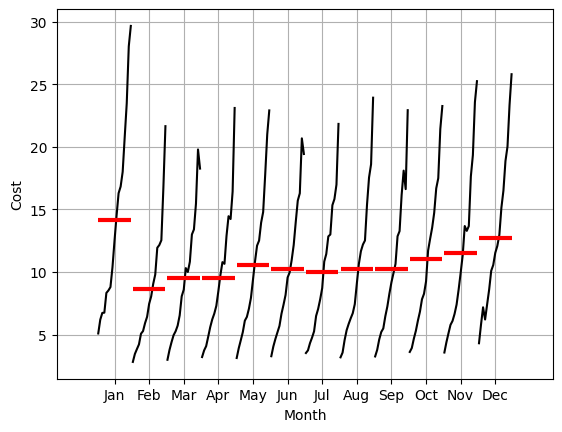

In [40]:
fig, ax = plt.subplots()
sm.graphics.tsa.month_plot(a10.Cost, ax=ax)
ax.set(xlabel='Month', ylabel='Cost')
ax.grid(True)

## Seasonal subseries plots
  * Data for each season collected together in time plot as separate time series.
  * Enables the underlying seasonal pattern to be seen clearly, and changes in seasonality over time to be visualized.

In [41]:
aus_production

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1956-01-01,1956 Q1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1956-04-01,1956 Q2,213,5178.0,204.0,532,4436,6,1956-04-01,1956
1956-07-01,1956 Q3,227,5297.0,208.0,561,4806,7,1956-07-01,1956
1956-10-01,1956 Q4,308,5681.0,197.0,570,4418,6,1956-10-01,1956
1957-01-01,1957 Q1,262,5577.0,187.0,529,4339,5,1957-01-01,1957
...,...,...,...,...,...,...,...,...,...
2009-04-01,2009 Q2,398,NaN,NaN,2160,57471,238,2009-04-01,2009
2009-07-01,2009 Q3,419,NaN,NaN,2325,58394,252,2009-07-01,2009
2009-10-01,2009 Q4,488,NaN,NaN,2273,57336,210,2009-10-01,2009


In [42]:
beer = aus_production[['Quarter', 'Date', 'Beer']]#.reset_index(drop=True)

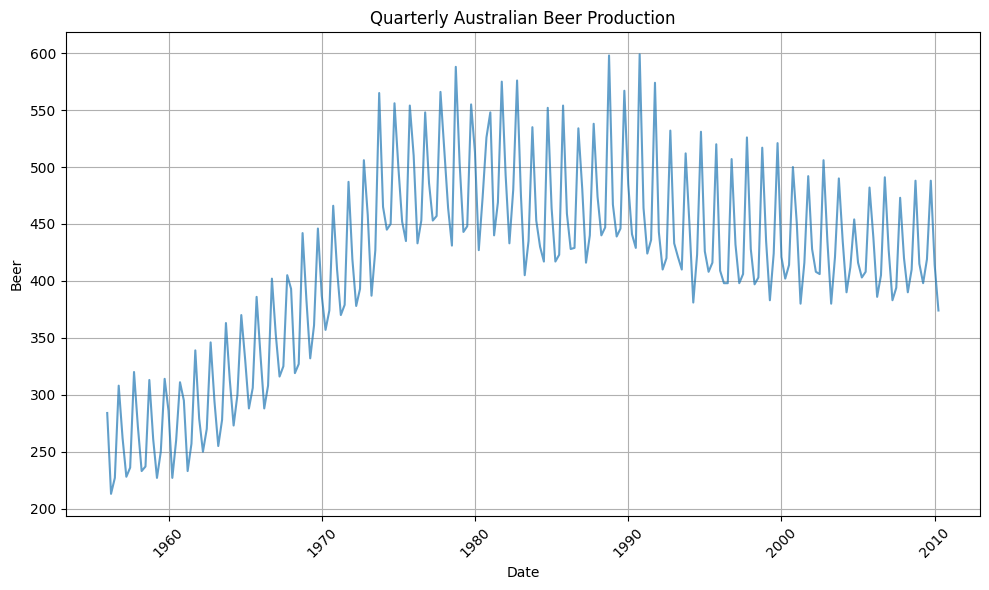

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(beer.index, beer['Beer'], marker='', linestyle='-', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Beer')
plt.title('Quarterly Australian Beer Production')

plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
beer

,Quarter,Date,Beer
Date,,,
1956-01-01,1956 Q1,1956-01-01,284
1956-04-01,1956 Q2,1956-04-01,213
1956-07-01,1956 Q3,1956-07-01,227
1956-10-01,1956 Q4,1956-10-01,308
1957-01-01,1957 Q1,1957-01-01,262
...,...,...,...
2009-04-01,2009 Q2,2009-04-01,398
2009-07-01,2009 Q3,2009-07-01,419
2009-10-01,2009 Q4,2009-10-01,488


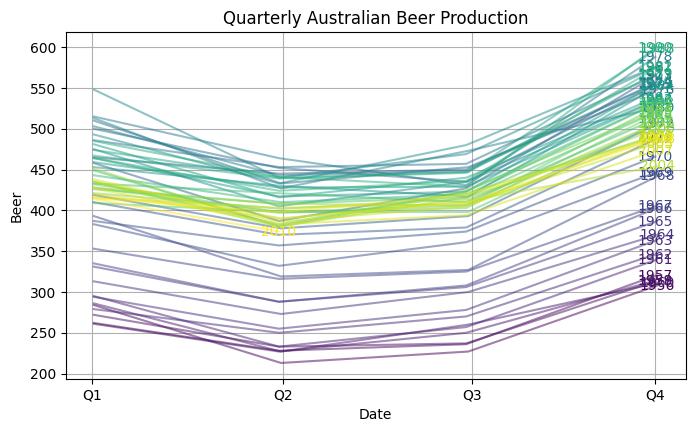

In [45]:
ax = plot_seasonal(beer, 'Beer', alpha=.5, figsize=sizets)
ax.set(xlabel='Quarter', ylabel='Beer')
xticks_values = [0, 93, 185, 274]
xtick_labels = ['Q1', 'Q2', 'Q3', 'Q4']
ax.set_xticks(xticks_values)
ax.set_xticklabels(xtick_labels)

for line in ax.lines:
    quarter_label = line.get_label()
    year = quarter_label[:4]
    x_pos = line.get_xdata()[-1]
    y_pos = line.get_ydata()[-1]

    color = line.get_color()
    # Adicionando o texto na linha com a mesma cor
    ax.text(x_pos, y_pos, f'{year}', ha='center', va='center', color=color)

plt.xlabel('Date')
plt.ylabel('Beer')
plt.title('Quarterly Australian Beer Production')
ax.grid(True)

In [46]:
beer.columns

Index(['Quarter', 'Date', 'Beer'], dtype='object')

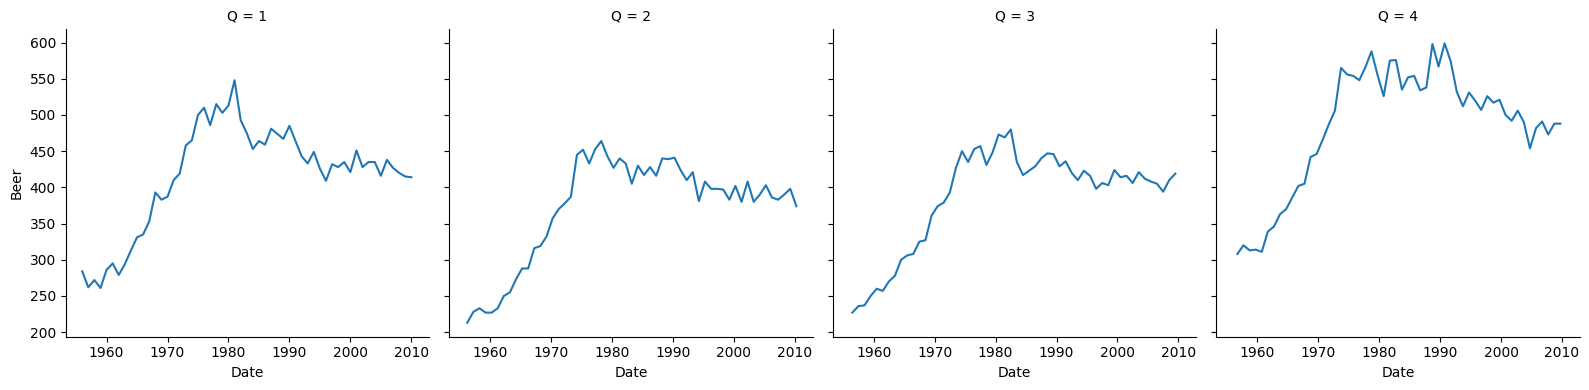

In [47]:
d = beer.assign(Q = beer.index.quarter)
g = sns.FacetGrid(d, col='Q', height=4, aspect=1,
                  sharey='row', margin_titles=True,
                  )
g = g.map(plt.plot, 'Date', 'Beer').set_titles('Q{col_name}')

## Multiple seasonal periods

In [48]:
vic_elec = (
    pd.read_csv('data/vic_elec.csv')
    .pipe(compute, lambda x: dict(Time = pd.to_datetime(x.Time)))
    .set_index('Time')
)

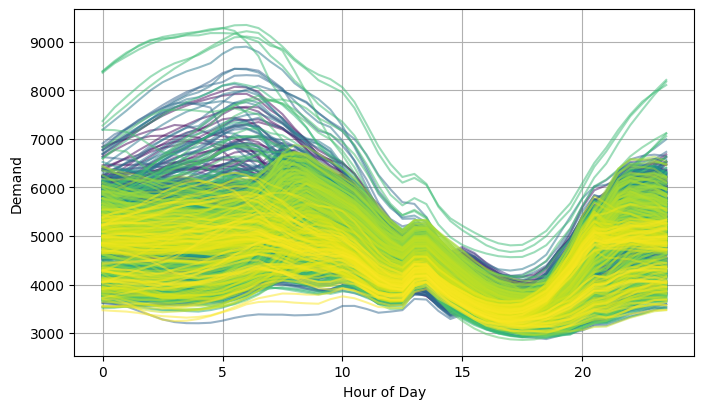

In [49]:
ax = plot_seasonal(vic_elec, 'Demand', period='d', alpha=.5, figsize=sizets)
ax.set(xlabel='Hour of Day', ylabel='Demand')
ax.grid()

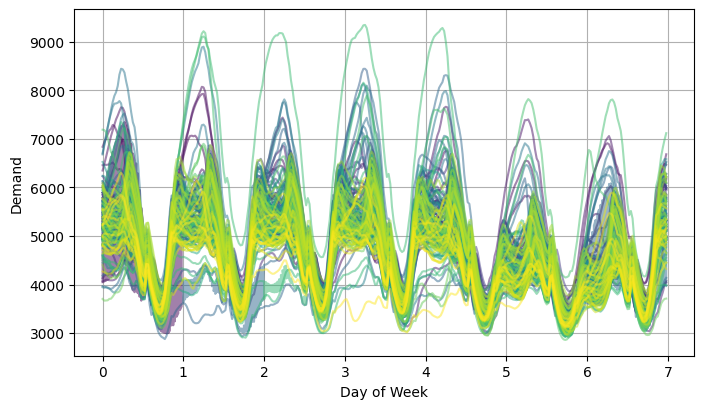

In [50]:
ax = plot_seasonal(vic_elec, 'Demand', period='W', alpha=.5, figsize=sizets)
ax.set(xlabel='Day of Week', ylabel='Demand')
ax.grid()

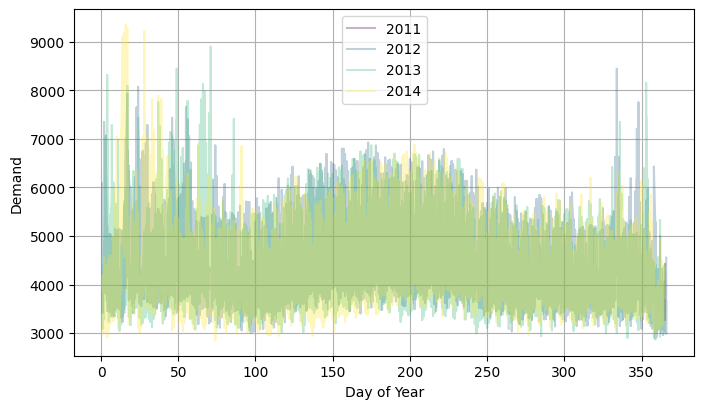

In [51]:
ax = plot_seasonal(vic_elec, 'Demand', period='y', alpha=.3, figsize=sizets)
ax.legend()
ax.set(xlabel='Day of Year', ylabel='Demand')
ax.grid()


## Seasonal subseries plots

In [52]:
!head data/tourism.csv

Quarter,Region,State,Purpose,Trips
1998 Q1,Adelaide,South Australia,Business,135.0776903
1998 Q2,Adelaide,South Australia,Business,109.987316
1998 Q3,Adelaide,South Australia,Business,166.0346866
1998 Q4,Adelaide,South Australia,Business,127.1604643
1999 Q1,Adelaide,South Australia,Business,137.4485333
1999 Q2,Adelaide,South Australia,Business,199.9125861
1999 Q3,Adelaide,South Australia,Business,169.3550898
1999 Q4,Adelaide,South Australia,Business,134.3579372
2000 Q1,Adelaide,South Australia,Business,154.034398


In [53]:
holidays = (
    pd.read_csv('data/tourism.csv')
    .pipe(compute, lambda x: dict(
        # Substitui "YYYY Q1" por "YYYY-01-01", "YYYY-04-01" etc.
        date=pd.to_datetime(x.Quarter.str.replace(r'(\d{4}) Q(\d)', lambda m: f'{m.group(1)}-{int(m.group(2))*3-2:02d}-01', regex=True))
    ))
    .groupby(['State', 'Quarter', 'date'], as_index=False)
    .agg({
        'Trips': 'sum',
    })
    .reset_index()
    .set_index('date', drop=False)
)


In [54]:
holidays

,index,State,Quarter,date,Trips
date,,,,,
1998-01-01,0,ACT,1998 Q1,1998-01-01,551.001921
1998-04-01,1,ACT,1998 Q2,1998-04-01,416.025623
1998-07-01,2,ACT,1998 Q3,1998-07-01,436.029011
1998-10-01,3,ACT,1998 Q4,1998-10-01,449.798445
1999-01-01,4,ACT,1999 Q1,1999-01-01,378.572817
...,...,...,...,...,...
2016-10-01,635,Western Australia,2016 Q4,2016-10-01,2656.330701
2017-01-01,636,Western Australia,2017 Q1,2017-01-01,2570.911689
2017-04-01,637,Western Australia,2017 Q2,2017-04-01,2438.487939


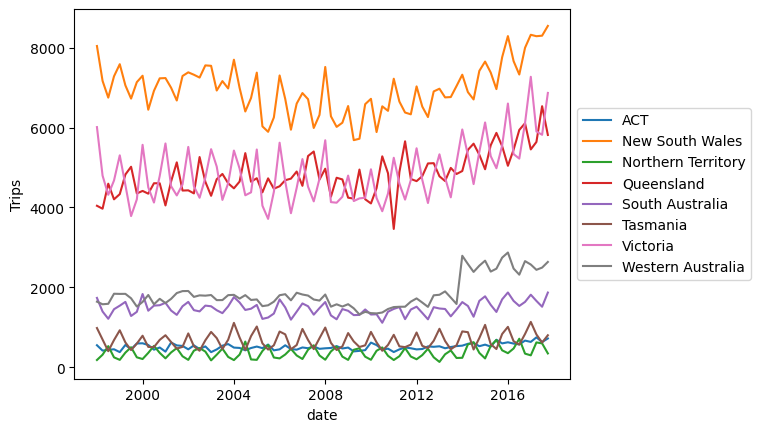

In [55]:
legend_right = dict(loc='center left', bbox_to_anchor=[1, .5])
ax = sns.lineplot(x='date', y='Trips', data=holidays, hue='State')
ax.legend(**legend_right)


In [56]:
holidays = holidays.assign(Q = holidays.index.quarter)
holidays.head(3)

,index,State,Quarter,date,Trips,Q
date,,,,,,
1998-01-01,0,ACT,1998 Q1,1998-01-01,551.001921,1
1998-04-01,1,ACT,1998 Q2,1998-04-01,416.025623,2
1998-07-01,2,ACT,1998 Q3,1998-07-01,436.029011,3


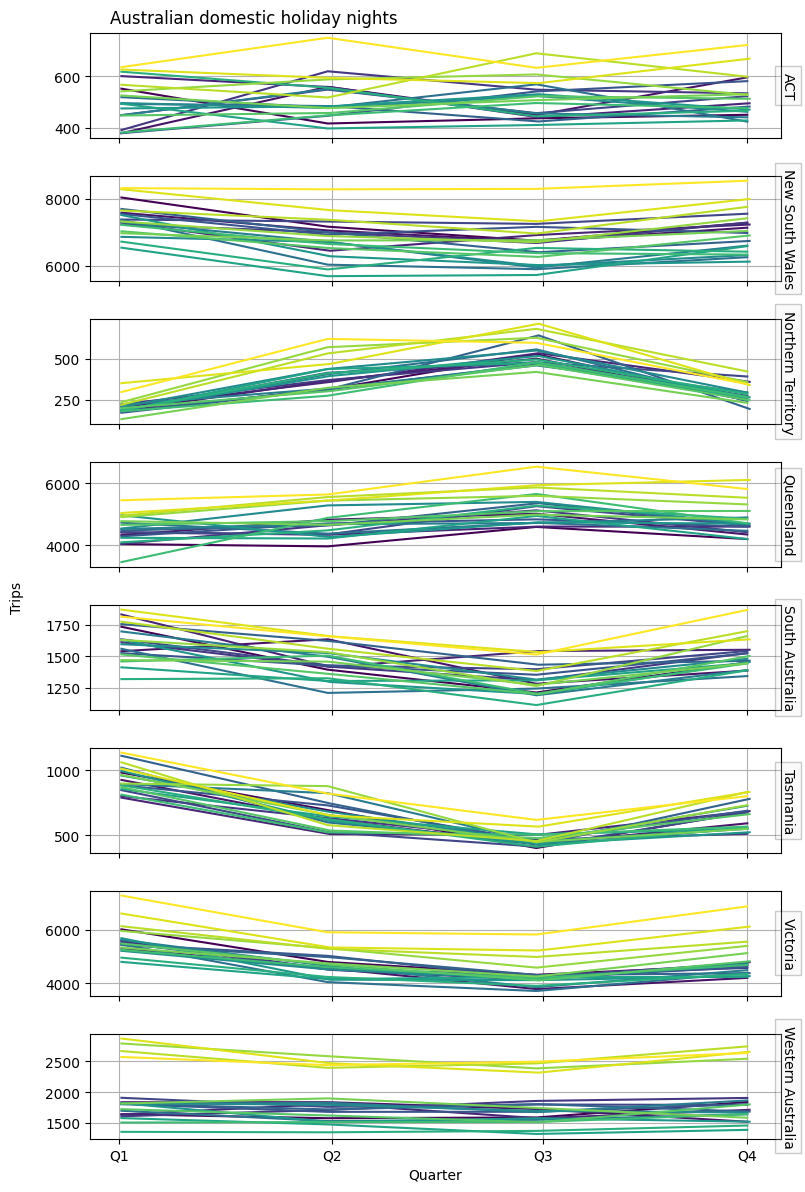

In [57]:
def rlabel(ax, label=None, bbox=None, **kw):
    """Add a right-side axis title."""
    label = label or ax  # Se label for None, usa ax como o label
    bbox = bbox or dict(facecolor='.9', alpha=0.2)  # Padrão de bbox
    ax.text(1, .5, label, rotation=-90, ha='left', va='center', transform=ax.transAxes,
            bbox=bbox, **kw)

fig, axs = plt.subplots(holidays.State.nunique(), 1, figsize=(8,12), sharex=True)
for ax, (State, d) in zip(axs, holidays.groupby('State')):
    plot_seasonal(d.set_index('date'), 'Trips', ax=ax)
    rlabel(ax, label=State)  # Passa diretamente o 'State' como label
    ax.grid(True)

ax.set(xlabel='Quarter')
xticks_values = [0, 93, 185, 274]
xtick_labels = ['Q1', 'Q2', 'Q3', 'Q4']
ax.set_xticks(xticks_values)
ax.set_xticklabels(xtick_labels)
suptitle('Australian domestic holiday nights')
fig.text(0, .5, 'Trips', rotation=90, va='center')
plt.tight_layout()
fig.subplots_adjust(top=.97, left=.1)


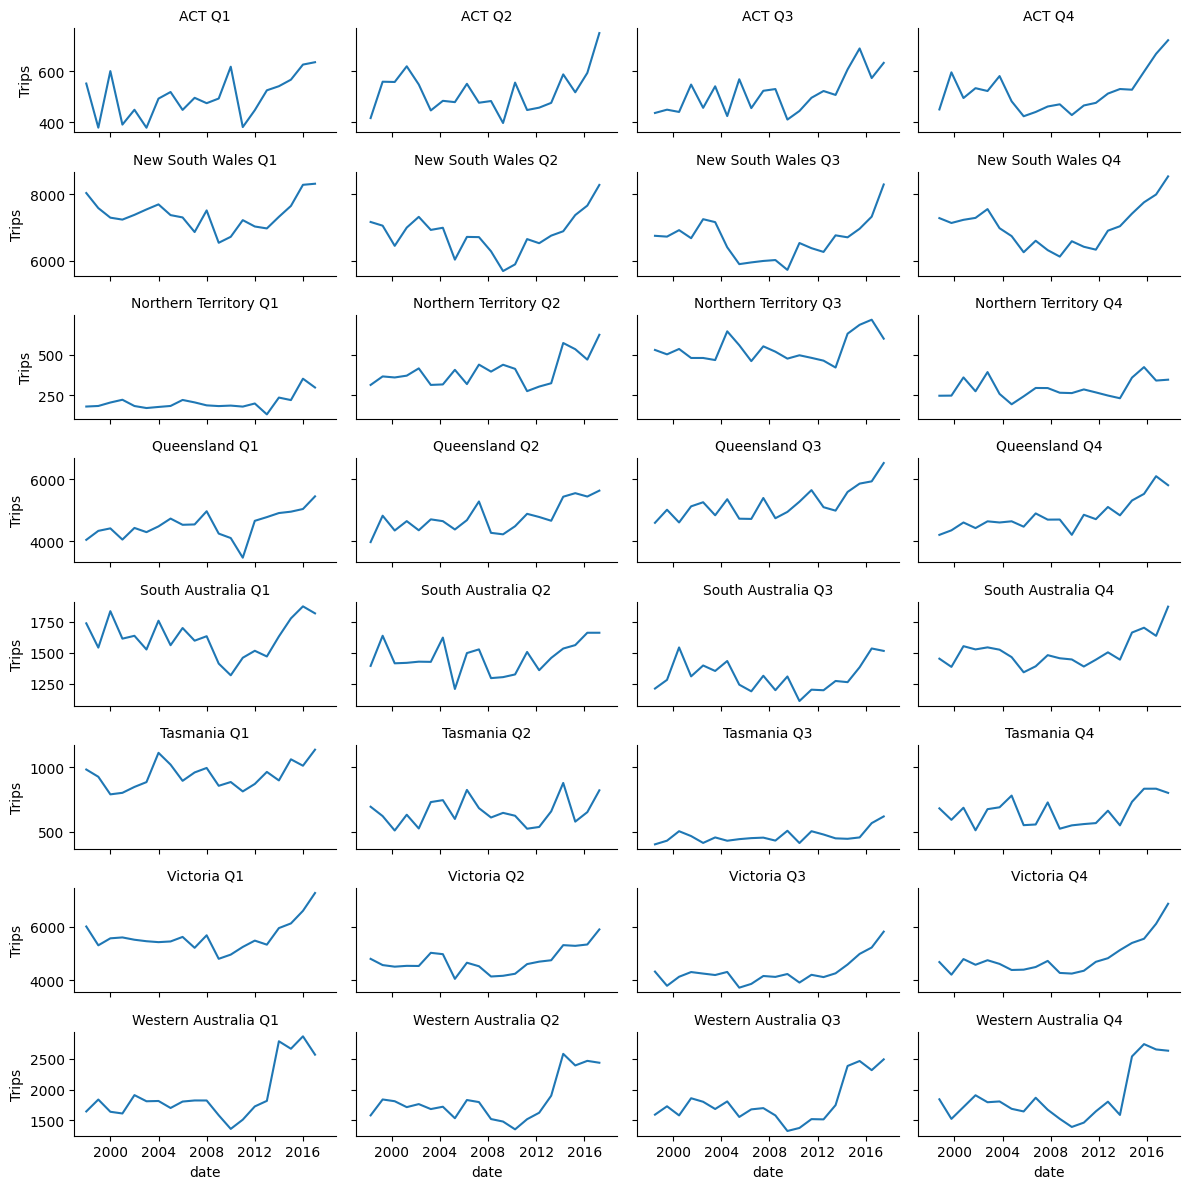

In [54]:
d = holidays.assign(Q = holidays.index.quarter)
g = sns.FacetGrid(d, col='Q', row='State', height=1.5, aspect=2,
                  sharey='row', #margin_titles=True,
                  )
g = g.map(plt.plot, 'date', 'Trips').set_titles('{row_name} Q{col_name}')

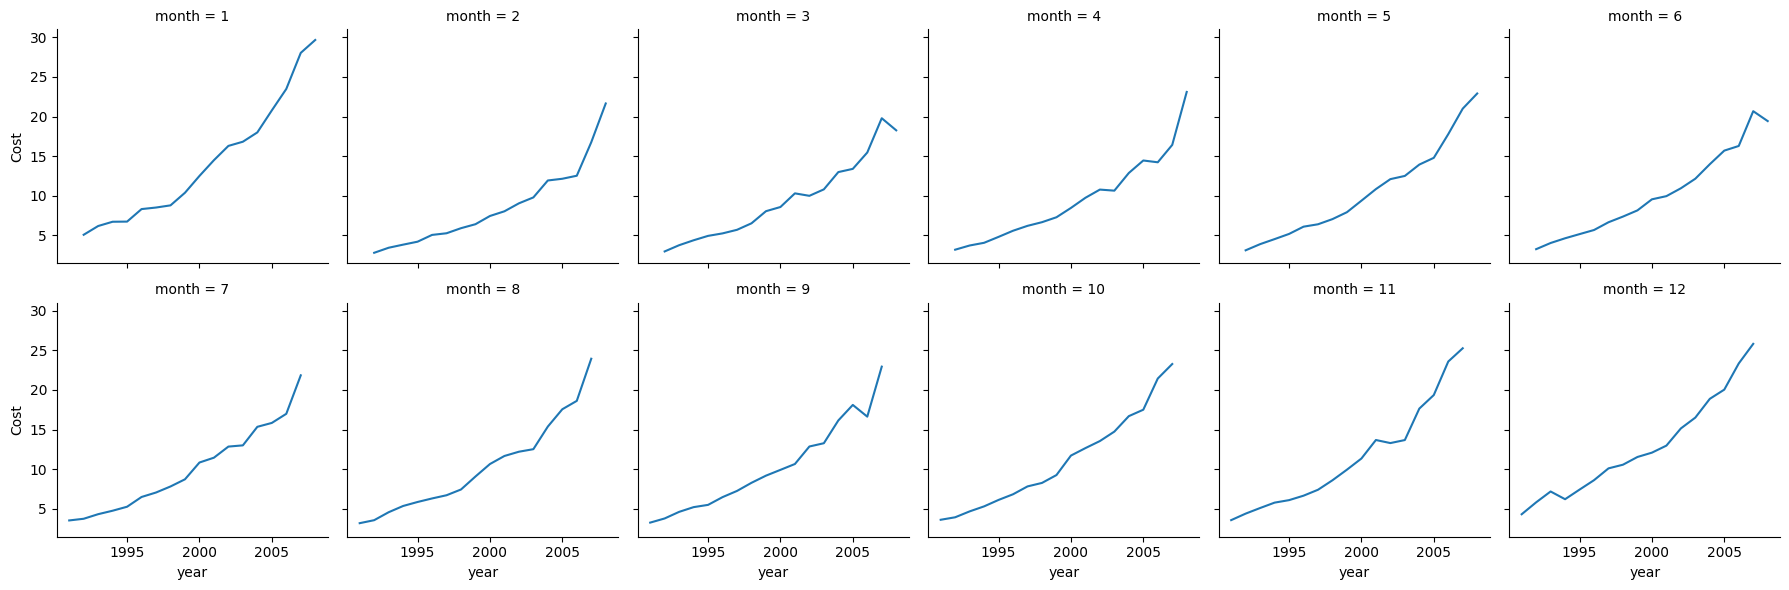

In [55]:
d = a10.assign(year=a10.index.year, month=a10.index.month)
g = sns.FacetGrid(d, col='month', col_wrap=6)
g.map(plt.plot, 'year', 'Cost')

## Scatterplots

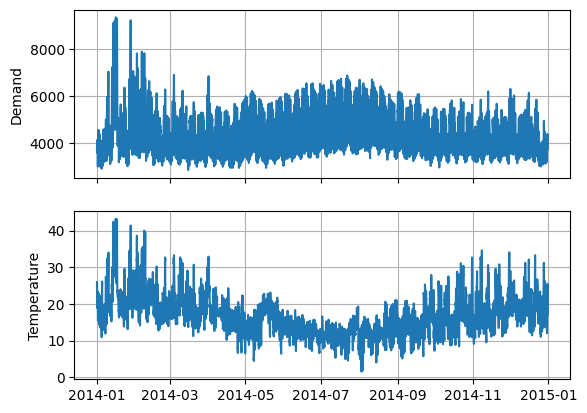

In [58]:
fig, axs = plt.subplots(2, sharex=True)
d = vic_elec[vic_elec.index.year == 2014]
ax = axs[0]
ax.plot(d.Demand)
ax.set(xlabel='', ylabel='Demand')
ax.grid(True)

ax = axs[1]
ax.plot(d.Temperature)
ax.set(xlabel='', ylabel='Temperature')
ax.grid(True)

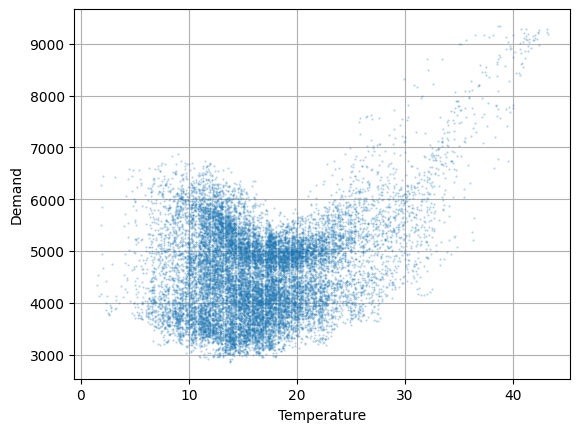

In [57]:
fig, ax = plt.subplots()
ax.plot(d.Temperature, d.Demand, '.', alpha=.33, ms=1)
ax.set(xlabel='Temperature', ylabel='Demand')
ax.grid(True)

## Pair plots

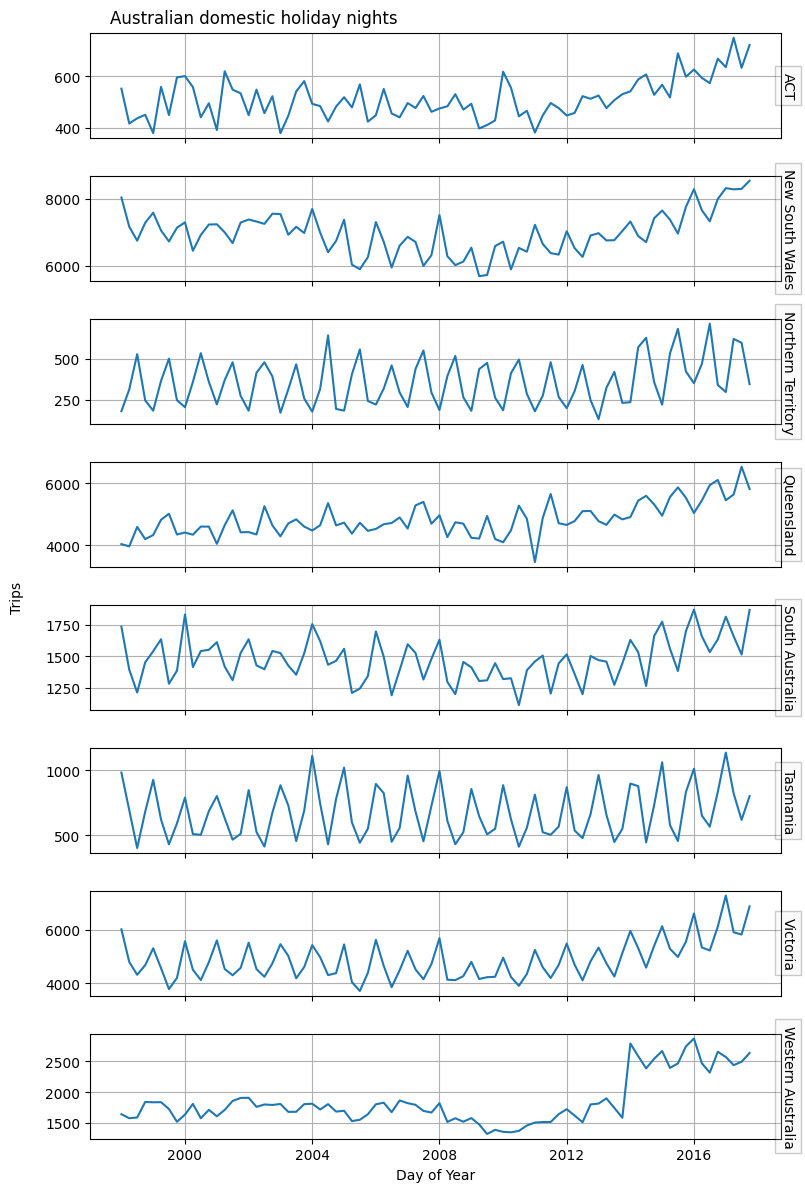

In [62]:
fig, axs = plt.subplots(holidays.State.nunique(), 1, figsize=(8,12), sharex=True)
for ax, (State, d) in zip(axs, holidays.groupby('State')):
    ax.plot(d.Trips)
    rlabel(ax, label=State)  # Passa diretamente o 'State' como label
    ax.grid()

ax.set(xlabel='Day of Year')
suptitle('Australian domestic holiday nights')
fig.text(0, .5, 'Trips', rotation=90, va='center')
plt.tight_layout()
fig.subplots_adjust(top=.97, left=.1)


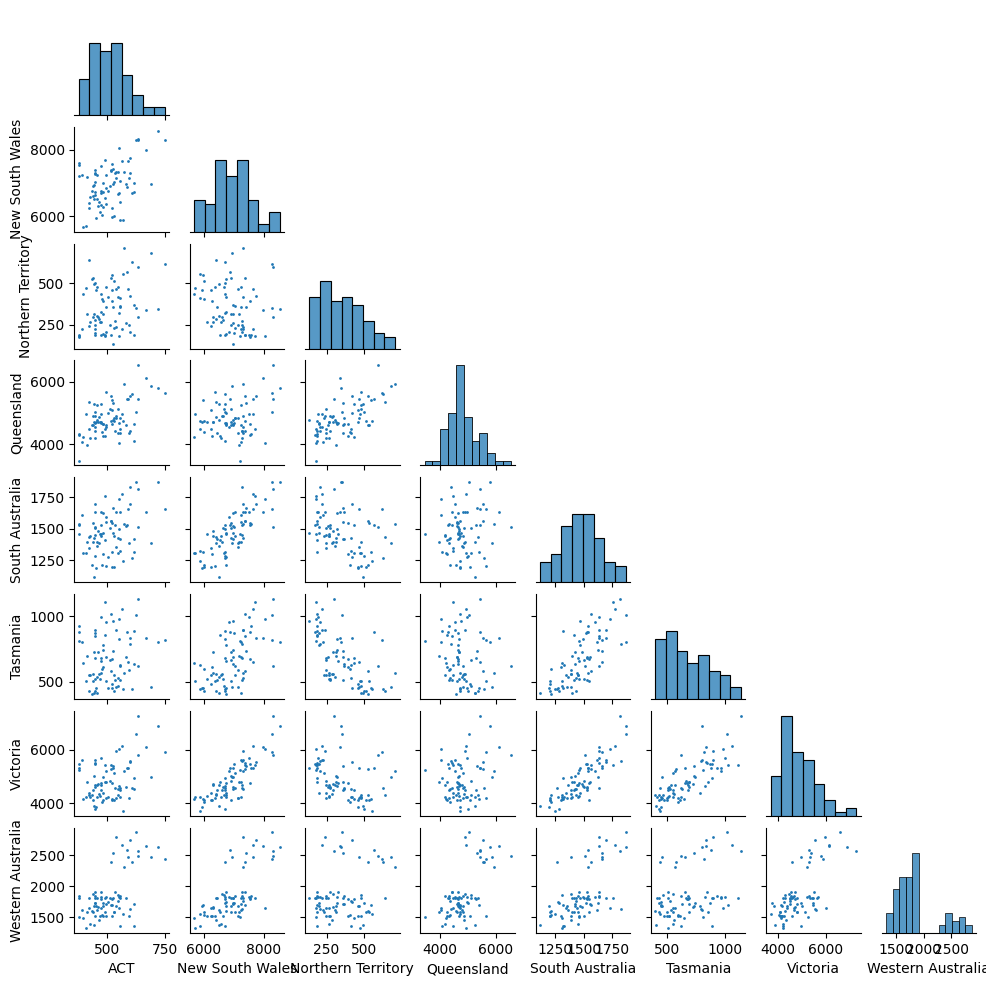

In [61]:
d = holidays.pivot(index='date', columns='State', values='Trips')
sns.pairplot(d, plot_kws=dict(linewidth=0, s=4), corner=True, height=1.25)

## Lag Plots

In [63]:
d = pd.read_csv('data/aus_production.csv')
recent_production = (
    d
    .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))
    .pipe(compute, lambda x: dict(Year=x.Date.dt.year))
    .query('Year >= 1992')
    .set_index('Date', drop=False)
    .drop(columns='Date Year'.split())
)

recent_production

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_16991/1183469135.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))


,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
Date,,,,,,,
1992-01-01,1992 Q1,443,5777.0,383.0,1289,38332,117
1992-04-01,1992 Q2,410,5853.0,404.0,1501,39774,151
1992-07-01,1992 Q3,420,6416.0,446.0,1539,42246,175
1992-10-01,1992 Q4,532,5825.0,420.0,1568,38498,129
1993-01-01,1993 Q1,433,5724.0,394.0,1450,39460,116
...,...,...,...,...,...,...,...
2009-04-01,2009 Q2,398,NaN,NaN,2160,57471,238
2009-07-01,2009 Q3,419,NaN,NaN,2325,58394,252
2009-10-01,2009 Q4,488,NaN,NaN,2273,57336,210


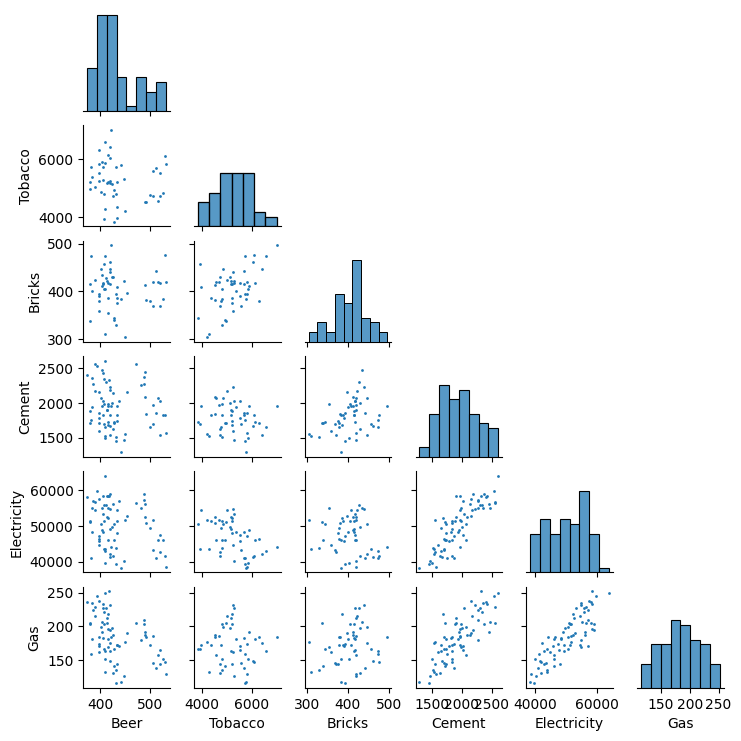

In [65]:
sns.pairplot(recent_production, plot_kws=dict(linewidth=0, s=4), corner=True, height=1.25)

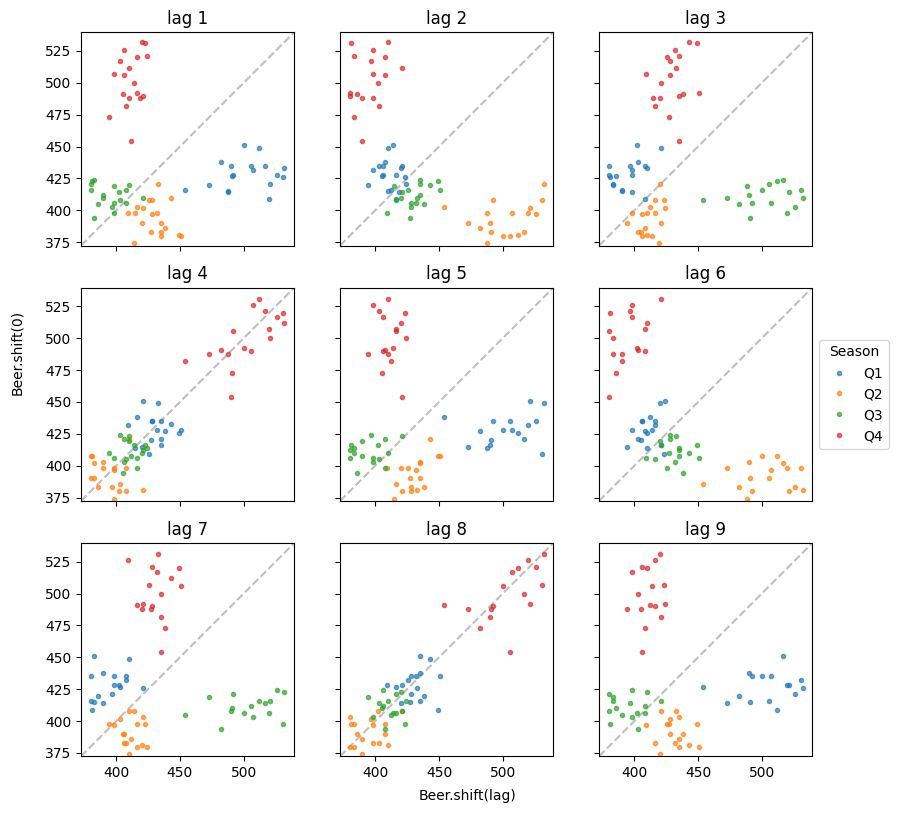

In [66]:
fig, axs = plt.subplots(3, 3, figsize=(9,8), sharex=True, sharey=True)
D = recent_production.copy()
D = pd.DataFrame({lag: D.Beer.shift(lag) for lag in range(10)})
D['q'] = recent_production.index.quarter
for (i, ax) in enumerate(axs.ravel()):
    for (q, d) in D.groupby('q'):
        ax.plot(d[i+1], d[0], '.', alpha=.66, label=f'Q{q}')
        lim = ax.get_xlim()
    ax.plot(lim, lim, 'k--', alpha=.25, zorder=-10)
    ax.set(xlim=lim, ylim=lim, title=f'lag {i+1}', aspect='equal')
axs.ravel()[5].legend(loc='center left', bbox_to_anchor=[1, .5], title='Season')
fig.text(.5, -.01, 'Beer.shift(lag)', ha='center', va='bottom')
fig.text(0, .5, 'Beer.shift(0)', ha='center', va='bottom', rotation=90)
plt.tight_layout()

## Lagged scatterplots
  * Each graph shows $y_t$ plotted against $y_{t-k}$ for
different values of $k$.
  * The autocorrelations are the correlations associated
with these scatterplots.
  * ACF (autocorrelation function):
     * $r_1=\text{Correlation}(y_{t}, y_{t-1})$
     * $r_2=\text{Correlation}(y_{t}, y_{t-2})$
     * $r_3=\text{Correlation}(y_{t}, y_{t-3})$
     * etc.

We measure the relationship between:

  * $y_{t}$ and $y_{t-1}$
  * $y_{t}$ and $y_{t-2}$
  * $y_{t}$ and $y_{t-3}$
  * etc.

## Autocorrelation

**Covariance** and **correlation**: measure extent of **linear relationship** between two variables ($y$ and $X$).

**Autocovariance** and **autocorrelation**: measure linear relationship between **lagged values** of a time series $y$.

## Autocorrelation

We denote the sample autocovariance at lag $k$ by $c_k$ and the sample autocorrelation at lag $k$ by $r_k$.  Then define

$$c_k = \frac{1}{T}\sum_{t=k+1}^T (y_t-\bar{y})(y_{t-k}-\bar{y}) \qquad\text{and}\qquad r_{k} = c_k/c_0
$$
  * $r_1$ indicates how successive values of  $y$  relate to each other
  * $r_2$ indicates how  $y$ values two periods apart relate to each other
  * $r_k$ is *almost* the same as the sample correlation between $y_t$ and $y_{t-k}$.

## Autocorrelation

Results for first 9 lags for beer data:

In [63]:
beer.head(9)

,Quarter,Date,Beer
Date,,,
1956-01-01,1956 Q1,1956-01-01,284
1956-04-01,1956 Q2,1956-04-01,213
1956-07-01,1956 Q3,1956-07-01,227
1956-10-01,1956 Q4,1956-10-01,308
1957-01-01,1957 Q1,1957-01-01,262
1957-04-01,1957 Q2,1957-04-01,228
1957-07-01,1957 Q3,1957-07-01,236
1957-10-01,1957 Q4,1957-10-01,320
1958-01-01,1958 Q1,1958-01-01,272


In [67]:
import statsmodels.api as sm

acf_result = sm.tsa.acf(recent_production['Beer'], nlags=9)
acf_result

array([ 1.        , -0.10190904, -0.65661956, -0.06027634,  0.8685293 ,
       -0.08915021, -0.63513179, -0.05416215,  0.83224495, -0.10787557])

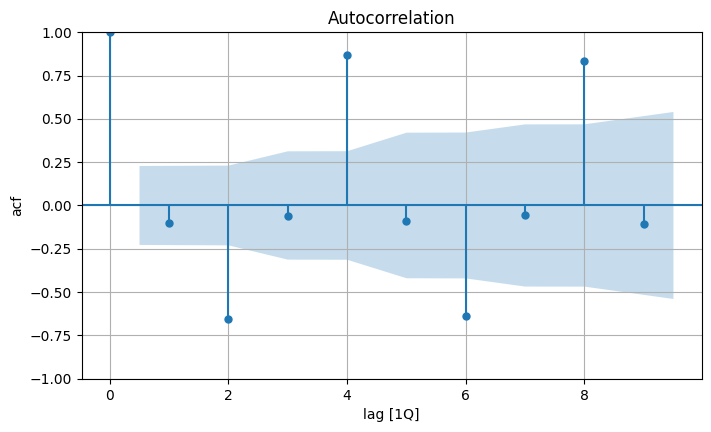

In [65]:
fig, ax = plt.subplots(figsize=sizets)
sm.graphics.tsa.plot_acf(recent_production.Beer, ax=ax, lags=9)
ax.set(ylim=(-1,1), xlabel='lag [1Q]', ylabel='acf')
plt.grid(True)

  * Together, the autocorrelations at lags 1, 2, \dots, make up the **autocorrelation** or ACF.
  * The plot is known as a **correlogram**
  * $r_{4}$  higher than for the other lags. This is due to **the seasonal pattern in the data**: the peaks tend to be **4 quarters** apart and the troughs tend to be **2 quarters** apart.
  * $r_2$ is more negative than for the other lags because troughs tend to be 2 quarters behind peaks.

## Trend and seasonality in ACF plots
- When data have a trend, the autocorrelations for small lags tend to be large and positive.
- When data are seasonal, the autocorrelations will be larger at the seasonal lags (i.e., at multiples of the seasonal frequency)
- When data are trended and seasonal, you see a combination of these effects.

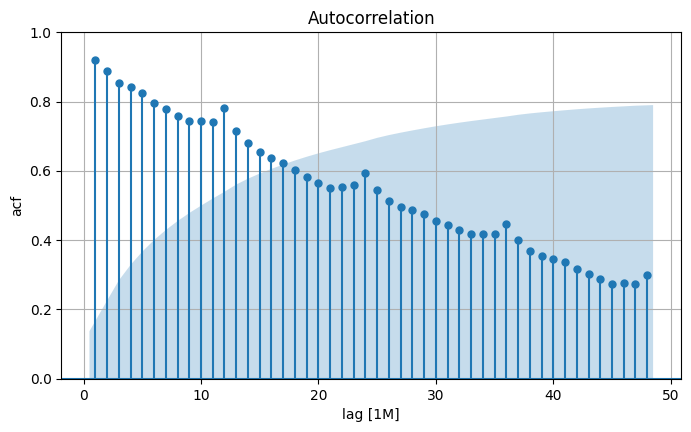

In [66]:
fig, ax = plt.subplots(figsize=sizets)
sm.graphics.tsa.plot_acf(a10.Cost, ax=ax, lags=np.r_[1:48+1])
ax.set(ylim=(0,1), xlabel='lag [1M]', ylabel='acf')
plt.grid()

## White noise

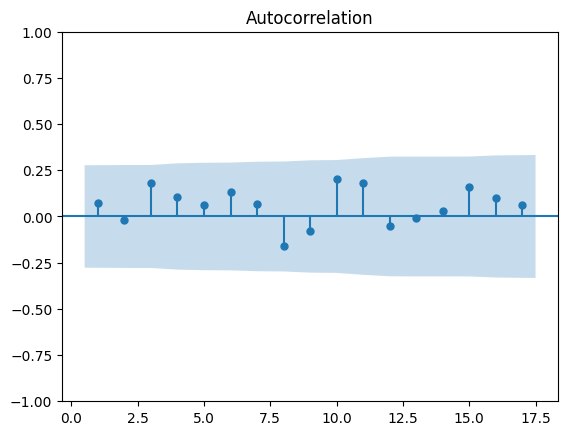

In [67]:
sm.graphics.tsa.plot_acf(np.random.normal(size=50), lags=np.r_[1:18]);

## US retail trade employment

In [68]:
!head data/us_employment.csv

Month,Series_ID,Title,Employed
1939 Jan,CEU0500000001,Total Private,25338
1939 Feb,CEU0500000001,Total Private,25447
1939 Mar,CEU0500000001,Total Private,25833
1939 Apr,CEU0500000001,Total Private,25801
1939 May,CEU0500000001,Total Private,26113
1939 Jun,CEU0500000001,Total Private,26485
1939 Jul,CEU0500000001,Total Private,26481
1939 Aug,CEU0500000001,Total Private,26848
1939 Sep,CEU0500000001,Total Private,27468


/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_16991/887493121.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us_employment = pd.read_csv("data/us_employment.csv", parse_dates=['Month'])


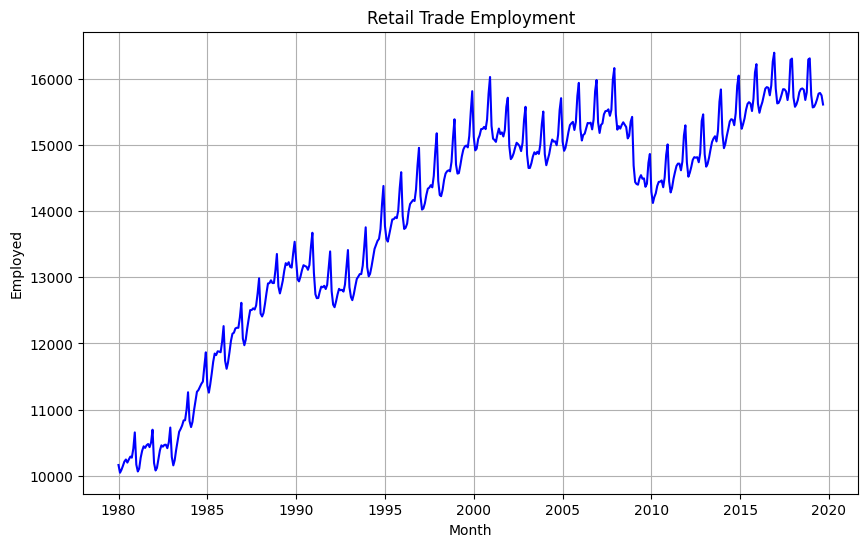

In [68]:
us_employment = pd.read_csv("data/us_employment.csv", parse_dates=['Month'])
retail = us_employment[us_employment['Title'] == 'Retail Trade']
retail = retail[retail['Month'].dt.year >= 1980]
plt.figure(figsize=(10, 6))
plt.plot(retail['Month'], retail['Employed'], label='Employed', color='b')
plt.xlabel('Month')
plt.ylabel('Employed')
plt.title('Retail Trade Employment')
plt.grid(True)
plt.show()

In [72]:
retail.head()

,Month,Series_ID,Title,Employed
49911,1980-01-01,CEU4200000001,Retail Trade,10162.8
49912,1980-02-01,CEU4200000001,Retail Trade,10046.1
49913,1980-03-01,CEU4200000001,Retail Trade,10089.0
49914,1980-04-01,CEU4200000001,Retail Trade,10150.5
49915,1980-05-01,CEU4200000001,Retail Trade,10214.9


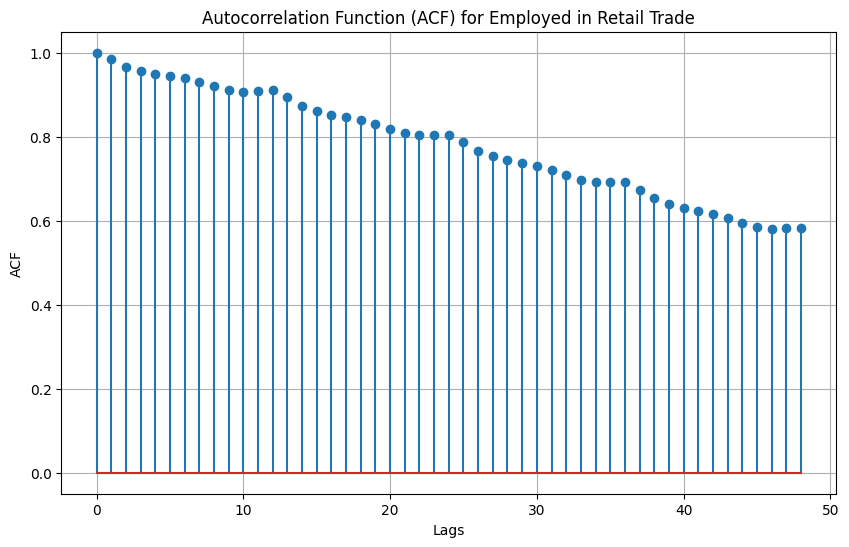

In [69]:
acf_result = sm.tsa.acf(retail['Employed'], nlags=48)

plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_result)), acf_result)
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.title('Autocorrelation Function (ACF) for Employed in Retail Trade')
plt.grid(True)
plt.show()


## Google stock price

In [70]:
google_2015 = (
    gafa_stock[gafa_stock['Symbol'] == 'GOOG']
    .loc[gafa_stock['Date'].dt.year == 2015, ['Date', 'Close']]
)
google_2015

,Date,Close
4026,2015-01-02,521.937744
4027,2015-01-05,511.057617
4028,2015-01-06,499.212799
4029,2015-01-07,498.357513
4030,2015-01-08,499.928864
...,...,...
4273,2015-12-24,748.400024
4274,2015-12-28,762.510010
4275,2015-12-29,776.599976
4276,2015-12-30,771.000000


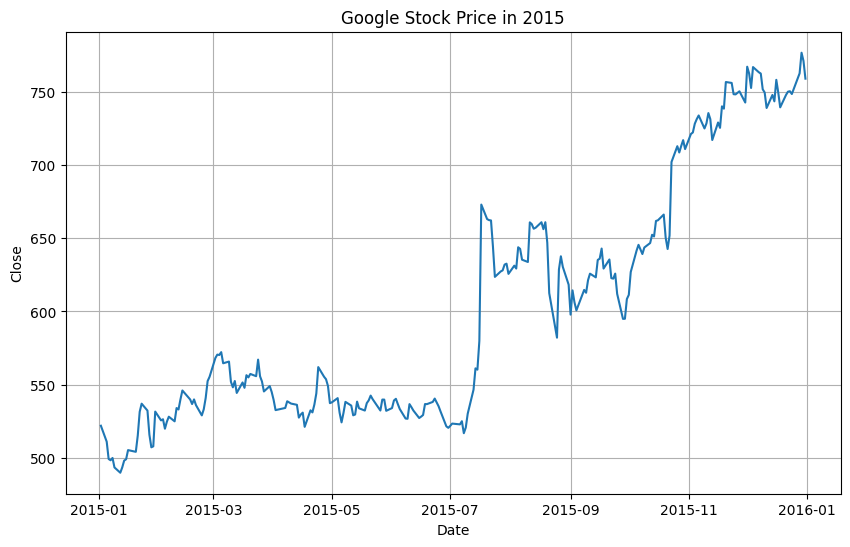

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(google_2015['Date'], google_2015['Close'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Google Stock Price in 2015')
plt.grid(True)
plt.show()

In [73]:
acf_result = sm.tsa.acf(google_2015['Close'], nlags=100)
acf_result

array([ 1.        ,  0.98151993,  0.95945528,  0.93749541,  0.91803632,
        0.90062125,  0.88331287,  0.86533485,  0.84879216,  0.8336546 ,
        0.81817364,  0.80216195,  0.78723638,  0.77346251,  0.76135805,
        0.74824629,  0.73475248,  0.7188027 ,  0.69969664,  0.67957676,
        0.66227747,  0.64230618,  0.62170388,  0.60313077,  0.58476915,
        0.5670424 ,  0.55105332,  0.53440695,  0.5181333 ,  0.50201004,
        0.48685681,  0.47446962,  0.46245948,  0.45227171,  0.44005069,
        0.42786085,  0.41694929,  0.40527802,  0.39415139,  0.38423198,
        0.3746151 ,  0.36442299,  0.35122163,  0.33854935,  0.32622254,
        0.31441425,  0.30255994,  0.29154515,  0.28254078,  0.27725441,
        0.27408951,  0.2719671 ,  0.27032595,  0.26757726,  0.26515198,
        0.26303109,  0.26049678,  0.25745846,  0.25446381,  0.25005179,
        0.24345846,  0.23608151,  0.22805035,  0.22028868,  0.21546026,
        0.21153551,  0.20914468,  0.20814279,  0.20593553,  0.20

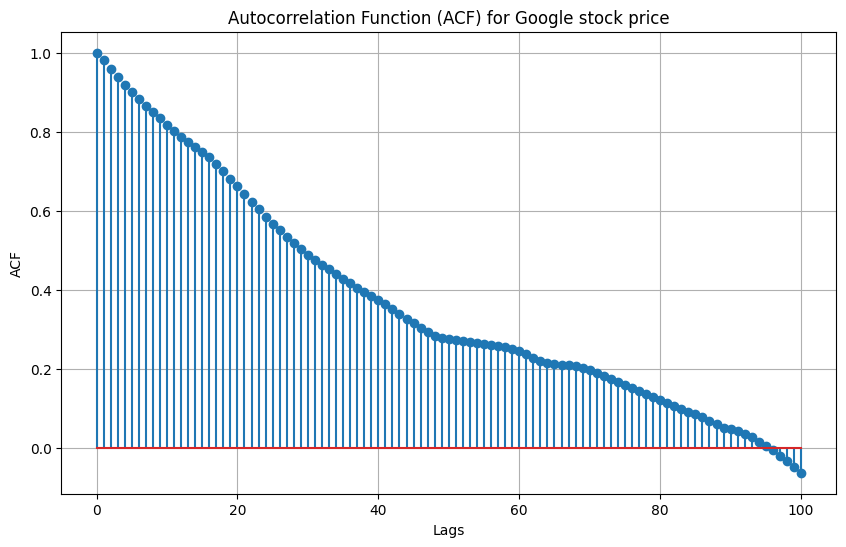

In [74]:
plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_result)), acf_result)
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.title('Autocorrelation Function (ACF) for Google stock price')
plt.grid(True)
plt.show()

# Quiz

In [73]:
cowtemp_data = [
    60, 70, 54, 56, 70, 66, 53, 95, 70, 69, 56, 70,
    70, 60, 60, 60, 50, 50, 48, 59, 50, 60, 70, 54, 46, 57, 57, 51,
    51, 59, 42, 46, 40, 40, 54, 47, 67, 50, 60, 54, 55, 50, 55, 54,
    47, 48, 54, 42, 43, 62, 49, 41, 45, 40, 49, 46, 54, 54, 60, 58,
    52, 47, 53, 39, 55, 45, 47, 41, 48, 42, 45, 48, 52, 49, 53
]


cowtemp = pd.Series(cowtemp_data)

In [74]:
us_deaths = [
    9007, 8106, 8928, 9137, 10017, 10826, 11317, 10744, 9713, 9938, 9161, 8927,
    7750, 6981, 8038, 8422, 8714, 9512, 10120, 9823, 8743, 9129, 8710, 8680, 8162,
    7306, 8124, 7870, 9387, 9556, 10093, 9620, 8285, 8433, 8160, 8034, 7717, 7461,
    7776, 7925, 8634, 8945, 10078, 9179, 8037, 8488, 7874, 8647, 7792, 6957, 7726,
    8106, 8890, 9299, 10625, 9302, 8314, 8850, 8265, 8796, 7836, 6892, 7791, 8129,
    9115, 9434, 10484, 9827, 9110, 9070, 8633, 9240
]


date_range = pd.date_range(start="1973-01-01", periods=len(us_deaths), freq='ME')


usdeaths = pd.Series(us_deaths, index=date_range)
usdeaths.head(3)

1973-01-31    9007
1973-02-28    8106
1973-03-31    8928
Freq: ME, dtype: int64

In [75]:
airpass_data = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115, 126, 141, 135, 125, 149, 170, 170,
    158, 133, 114, 140, 145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193, 181,
    183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315, 364, 347,
    312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306, 315, 301, 356, 348,
    355, 422, 465, 467, 404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606,
    508, 461, 390, 432
]


airpass = pd.Series(airpass_data, index=pd.date_range(start="1949-01-01", periods=len(airpass_data), freq="ME"))
airpass

1949-01-31    112
1949-02-28    118
1949-03-31    132
1949-04-30    129
1949-05-31    121
             ... 
1960-08-31    606
1960-09-30    508
1960-10-31    461
1960-11-30    390
1960-12-31    432
Freq: ME, Length: 144, dtype: int64

In [76]:
mink_data = [
    37123, 34712, 29619, 21151, 24859, 25152, 42375, 50839, 61581, 61951,
    76231, 63264, 44730, 31094, 49452, 43961, 61727, 60334, 51404, 58451,
    73575, 74343, 27708, 31985, 39266, 44740, 60429, 72273, 79214, 79060,
    84244, 62590, 35072, 36160, 45600, 47508, 52290, 110824, 76503, 64303,
    83023, 40748, 35396, 29479, 42264, 58171, 50815, 51285, 70229, 76365,
    70407, 41839, 45978, 47813, 57620, 66549, 54673, 55996, 60053, 39169,
    21534, 17857, 21788, 33008
]


mink = pd.Series(mink_data, index=pd.date_range(start="1848", periods=len(mink_data), freq="YE"))


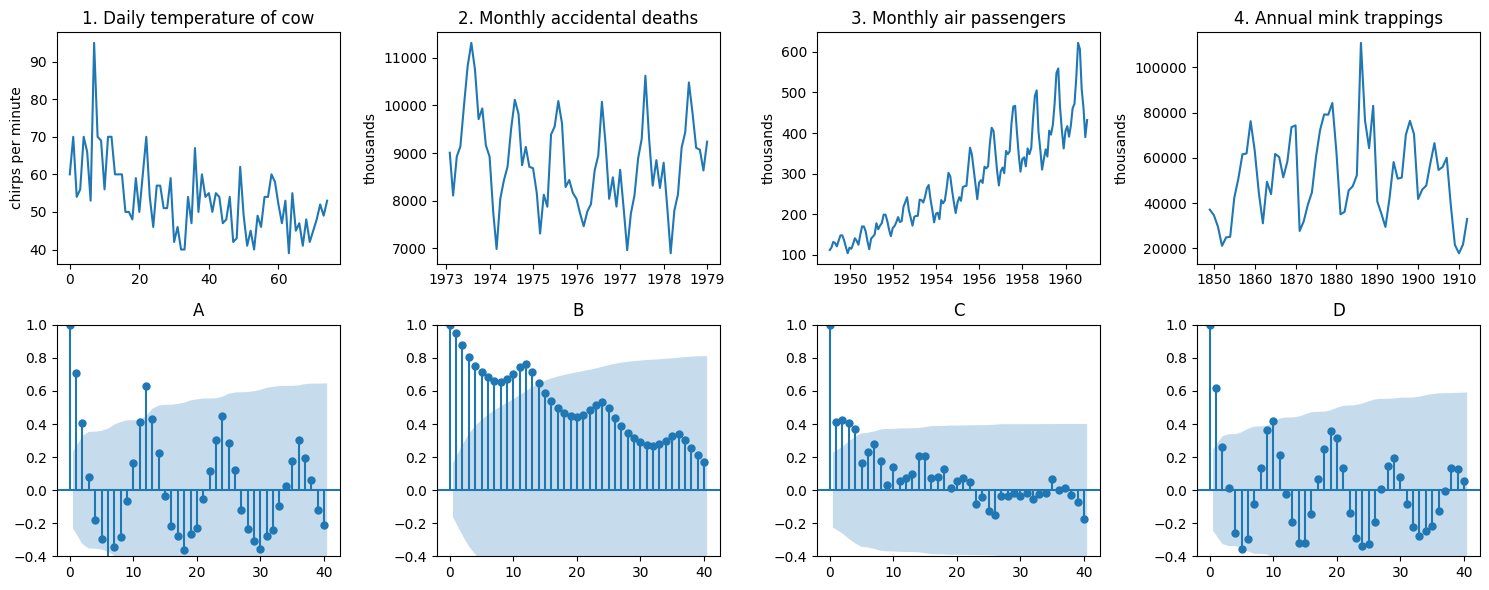

In [78]:
fig, axs = plt.subplots(2, 4, figsize=(15, 6))

axs[0, 0].plot(cowtemp)
axs[0, 0].set(title='1. Daily temperature of cow', xlabel='', ylabel='chirps per minute')

axs[0, 1].plot(usdeaths.index, usdeaths)
axs[0, 1].set(title='2. Monthly accidental deaths', xlabel='', ylabel='thousands')

axs[0, 2].plot(airpass.index, airpass)
axs[0, 2].set(title='3. Monthly air passengers', xlabel='', ylabel='thousands')

axs[0, 3].plot(mink.index, mink)
axs[0, 3].set(title='4. Annual mink trappings', xlabel='', ylabel='thousands')

plot_acf(usdeaths, ax=axs[1, 0], lags=40)
axs[1, 0].set(title='A', xlabel='', ylim=(-0.4, 1))

plot_acf(airpass, ax=axs[1, 1], lags=40)
axs[1, 1].set(title='B', xlabel='', ylim=(-0.4, 1))

plot_acf(cowtemp, ax=axs[1, 2], lags=40)
axs[1, 2].set(title='C', xlabel='', ylim=(-0.4, 1))

plot_acf(mink, ax=axs[1, 3], lags=40)
axs[1, 3].set(title='D', xlabel='', ylim=(-0.4, 1))


plt.tight_layout()




## White noise
>White noise data is uncorrelated across time with zero mean and constant variance.
(Technically, we require independence as well.)

In [79]:
white_noise = np.random.normal(size=50)

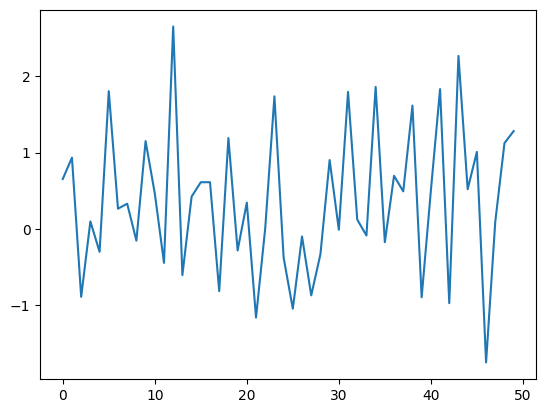

In [80]:
plt.plot(white_noise)

 * Sample autocorrelations for white noise series.
 * Expect each autocorrelation to be close to zero.
 * Blue area shows 95% critical values.

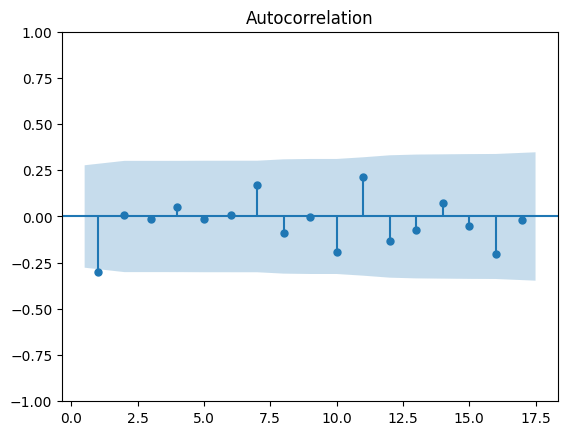

In [81]:
sm.graphics.tsa.plot_acf(white_noise, lags=np.r_[1:18]);

In [284]:
sm.tsa.acf(white_noise)

array([ 1.        , -0.07754719, -0.01924228,  0.10004196, -0.10459645,
       -0.00667874,  0.05694249, -0.19278276,  0.01984349,  0.09074662,
       -0.00569394,  0.00699872,  0.00735648, -0.10177924,  0.00199781,
        0.06362768, -0.01960046])

## Example: Pigs slaughtered


In [82]:
data = [
    76378, 71947, 33873, 96428, 105084, 95741, 110647, 100331, 94133, 103055, 90595, 101457, 76889, 81291, 91643,
    96228, 102736, 100264, 103491, 97027, 95240, 91680, 101259, 109564, 76892, 85773, 95210, 93771, 98202, 97906,
    100306, 94089, 102680, 77919, 93561, 117062, 81225, 88357, 106175, 91922, 104114, 109959, 97880, 105386, 96479,
    97580, 109490, 110191, 90974, 98981, 107188, 94177, 115097, 113696, 114532, 120110, 93607, 110925, 103312, 120184,
    103069, 103351, 111331, 106161, 111590, 99447, 101987, 85333, 86970, 100561, 89543, 89265, 82719, 79498, 74846,
    73819, 77029, 78446, 86978, 75878, 69571, 75722, 64182, 77357, 63292, 59380, 78332, 72381, 55971, 69750, 85472,
    70133, 79125, 85805, 81778, 86852, 69069, 79556, 88174, 66698, 72258, 73445, 76131, 86082, 75443, 73969, 78139,
    78646, 66269, 73776, 80034, 70694, 81823, 75640, 75540, 82229, 75345, 77034, 78589, 79769, 75982, 78074, 77588,
    84100, 97966, 89051, 93503, 84747, 74531, 91900, 81635, 89797, 81022, 78265, 77271, 85043, 95418, 79568, 103283,
    95770, 91297, 101244, 114525, 101139, 93866, 95171, 100183, 103926, 102643, 108387, 97077, 90901, 90336, 88732,
    83759, 99267, 73292, 78943, 94399, 92937, 90130, 91055, 106062, 103560, 104075, 101783, 93791, 102313, 82413,
    83534, 109011, 96499, 102430, 103002, 91815, 99067, 110067, 101599, 97646, 104930, 88905, 89936, 106723, 84307,
    114896, 106749, 87892, 100506
]

dates = pd.date_range(start='1980-01-01', periods=len(data), freq='ME')
pigs_df = pd.DataFrame(data, columns=['Count'], index=dates)

In [83]:
pigs_df

,Count
1980-01-31,76378
1980-02-29,71947
1980-03-31,33873
1980-04-30,96428
1980-05-31,105084
...,...
1995-04-30,84307
1995-05-31,114896
1995-06-30,106749
1995-07-31,87892


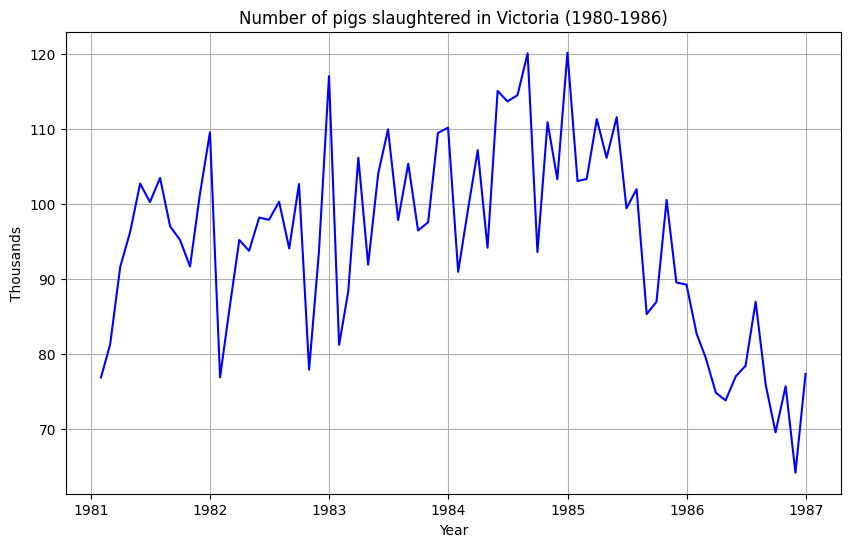

In [84]:
pigs_filtered = pigs_df[(pigs_df.index.year >= 1981) & (pigs_df.index.year <= 1986)]
plt.figure(figsize=(10, 6))
plt.plot(pigs_filtered.index, pigs_filtered['Count'] / 1000, color='blue')
plt.title('Number of pigs slaughtered in Victoria (1980-1986)')
plt.xlabel('Year')
plt.ylabel('Thousands')
plt.grid(True)
plt.show()


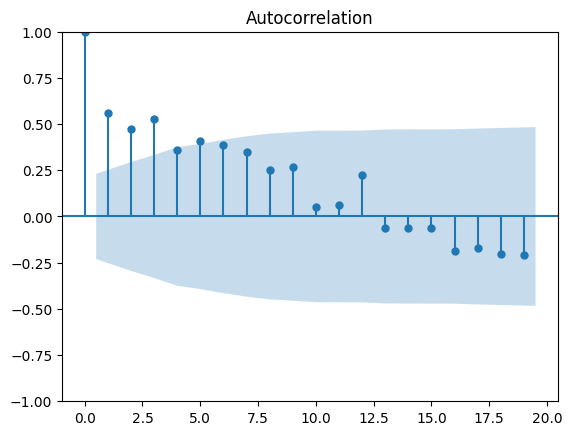

In [85]:
sm.graphics.tsa.plot_acf(pigs_filtered);

  * Difficult to detect pattern in time plot.
  * ACF shows significant autocorrelation for lag 1, 2, 3 and 5.
  * Indicate some seasonality.

These show the series is **not a white noise series**.

## Exercise

Use the gafa dataset. Analyze the Google stock price in 2018. Is it white noise?

Use the `tute1.csv` file. Columns B through D each contain a quarterly series, labelled Sales, AdBudget and GDP. Sales contains the quarterly sales for a small company over the period 1981-2005. AdBudget is the advertising budget and GDP is the gross domestic product. All series have been adjusted for inflation.
1. Read the file and create a time-series with it.
2. Construct time series plots of each of the three series.